In [15]:
import pandas as pd
import numpy as np

df = pd.read_csv('data/car_fuel_efficiency_2026.csv')
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [16]:
base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']
target = 'fuel_efficiency_mpg'

df = df[base + [target]].copy()
df.describe()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
count,10000.000000,9123.000000,10000.000000,10000.000000,10000.000000
mean,2268.807000,254.446016,4286.754000,1999.549500,29.997700
std,183.447355,22.844613,266.212491,14.207925,2.930245
min,1590.000000,171.000000,3320.000000,1975.000000,19.800000
25%,2150.000000,239.000000,4110.000000,1987.000000,28.000000
50%,2270.000000,254.000000,4280.000000,2000.000000,30.000000
75%,2390.000000,270.000000,4470.000000,2012.000000,31.900000
max,3110.000000,334.000000,5460.000000,2024.000000,41.200000


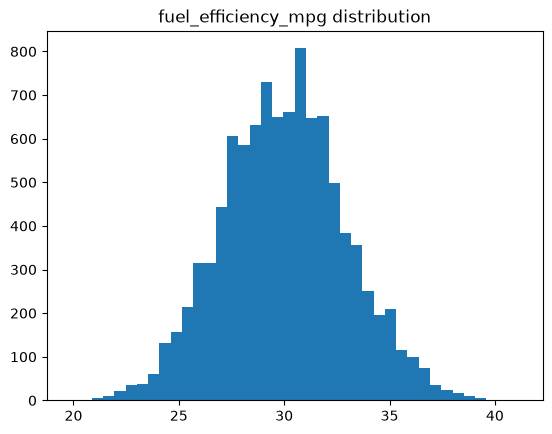

In [17]:
import matplotlib.pyplot as plt

plt.hist(df[target], bins=40)
plt.title('fuel_efficiency_mpg distribution')
plt.show()

In [21]:
print(df.isnull().sum())         
df['horsepower'].median()  

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64


np.float64(254.0)

In [22]:
def split(df, seed):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    idx = np.arange(n)
    np.random.seed(seed)
    np.random.shuffle(idx)

    df_shuf = df.iloc[idx].reset_index(drop=True)
    df_train = df_shuf.iloc[:n_train].reset_index(drop=True)
    df_val   = df_shuf.iloc[n_train:n_train+n_val].reset_index(drop=True)
    df_test  = df_shuf.iloc[n_train+n_val:].reset_index(drop=True)
    return df_train, df_val, df_test

df_train, df_val, df_test = split(df, seed=42)
len(df_train), len(df_val), len(df_test)

(6000, 2000, 2000)

In [23]:
def prepare_X(df_part, fill_value):
    return df_part[base].fillna(fill_value).values

def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])          # bias column
    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])    # Ridge penalty
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0], w_full[1:]            # w0 (bias), w (weights)

def predict(X, w0, w):
    return w0 + X.dot(w)

def rmse(y, y_pred):
    return np.sqrt(((y - y_pred) ** 2).mean())

In [24]:
y_train = df_train[target].values
y_val = df_val[target].values

# fill 0
X_train0 = prepare_X(df_train, 0)
X_val0 = prepare_X(df_val, 0)
w0_0, w_0 = train_linear_regression_reg(X_train0, y_train)
rmse_0 = rmse(y_val, predict(X_val0, w0_0, w_0))

# fill mean (train)
mean_hp = df_train['horsepower'].mean()
X_train_m = prepare_X(df_train, mean_hp)
X_val_m = prepare_X(df_val, mean_hp)
w0_m, w_m = train_linear_regression_reg(X_train_m, y_train)
rmse_m = rmse(y_val, predict(X_val_m, w0_m, w_m))

round(rmse_0, 3), round(rmse_m, 3)   

(np.float64(2.205), np.float64(2.202))

In [25]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0r, wr = train_linear_regression_reg(X_train0, y_train, r=r)
    pred = predict(X_val0, w0r, wr)
    print(r, round(rmse(y_val, pred), 2))

0 2.21
0.01 2.21
0.1 2.22
1 2.35
5 2.41
10 2.42
100 2.43


In [26]:
scores = []
for seed in range(10):
    dtr, dval, dtest = split(df, seed)
    Xtr = prepare_X(dtr, 0)
    Xval = prepare_X(dval, 0)
    w0s, ws = train_linear_regression_reg(Xtr, dtr[target].values, r=0)
    scores.append(rmse(dval[target].values, predict(Xval, w0s, ws)))

round(np.std(scores), 3)   

np.float64(0.029)

In [27]:
dtr, dval, dtest = split(df, seed=9)
df_trainval = pd.concat([dtr, dval]).reset_index(drop=True)

Xtv = prepare_X(df_trainval, 0)
ytv = df_trainval[target].values
Xtest = prepare_X(dtest, 0)
ytest = dtest[target].values

w0f, wf = train_linear_regression_reg(Xtv, ytv, r=0.001)
round(rmse(ytest, predict(Xtest, w0f, wf)), 3)   # 2.236

np.float64(2.236)